<a href="https://colab.research.google.com/github/bangaru01/C_programing/blob/main/Steirmol_Coneangle_Cycloetherification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# INSTALL
# ============================================================

!pip install -q morfeus-ml pandas numpy openpyxl


# ============================================================
# IMPORTS
# ============================================================

import os
import numpy as np
import pandas as pd

from google.colab import drive
from morfeus import Sterimol, read_xyz


# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================

drive.mount('/content/drive', force_remount=True)


# ============================================================
# XYZ FOLDER
# ============================================================

xyz_folder = "/content/drive/MyDrive/xyz_files"


# ============================================================
# FIXED ATOM NUMBERING
# ============================================================
#
# DDQ       = atoms 1–15
# Substrate = atoms 16–43
# C2        = atom 18
# H on C2   = atom 43
# R3        = atom 44 → last atom
#
# Sterimol axis = C18 → C44
# ============================================================

C2_ATOM = 18
R3_START_ATOM = 44


# ============================================================
# FIND ALL XYZ FILES AUTOMATICALLY
# ============================================================

xyz_files = sorted([
    f for f in os.listdir(xyz_folder)
    if f.lower().endswith(".xyz")
])


# ============================================================
# NUMBER OF XYZ FILES
# ============================================================

print("=" * 70)
print("XYZ FILE ANALYSIS")
print("=" * 70)

print(f"\nNumber of .xyz files found: {len(xyz_files)}")


if len(xyz_files) == 0:

    raise FileNotFoundError(
        f"No .xyz files found in:\n{xyz_folder}"
    )


print("\nFiles to be processed:")

for i, file in enumerate(xyz_files, 1):

    print(f"{i:3d}. {file}")


# ============================================================
# STORAGE
# ============================================================

results = []


# ============================================================
# PROCESS EVERY XYZ FILE
# ============================================================

for file_number, file in enumerate(xyz_files, 1):

    print("\n")
    print("=" * 70)
    print(
        f"FILE {file_number}/{len(xyz_files)} : {file}"
    )
    print("=" * 70)

    path = os.path.join(
        xyz_folder,
        file
    )

    # Default result dictionary
    result = {

        "File": file,

        "Status": "FAILED",

        "Number of atoms": np.nan,

        "R3": os.path.splitext(file)[0],

        "R3 atoms":
            "",

        "C18-C44 distance (Å)":
            np.nan,

        "Furthest R3 atom":
            np.nan,

        "C44-furthest R3 distance (Å)":
            np.nan,

        "Max perpendicular atom":
            np.nan,

        "Max perpendicular distance (Å)":
            np.nan,

        "Sterimol B1 (Å)":
            np.nan,

        "Sterimol B5 (Å)":
            np.nan,

        "Sterimol L (Å)":
            np.nan,

        "Cone Angle (deg)":
            np.nan,

        "Error":
            ""

    }


    try:

        # ====================================================
        # READ XYZ
        # ====================================================

        elements, coordinates = read_xyz(path)

        coordinates = np.asarray(
            coordinates,
            dtype=float
        )

        n_atoms = len(elements)

        result["Number of atoms"] = n_atoms


        # ====================================================
        # CHECK NUMBER OF ATOMS
        # ====================================================

        if n_atoms < R3_START_ATOM:

            raise ValueError(
                f"File contains only {n_atoms} atoms. "
                f"R3 must start at atom {R3_START_ATOM}."
            )


        # ====================================================
        # DEFINE R3
        # ====================================================

        R3_atoms = list(
            range(
                R3_START_ATOM,
                n_atoms + 1
            )
        )


        result["R3 atoms"] = (
            f"{R3_START_ATOM}-{n_atoms}"
        )


        print(
            f"Number of atoms = {n_atoms}"
        )

        print(
            f"R3 atoms = "
            f"{R3_START_ATOM}-{n_atoms}"
        )


        # ====================================================
        # C18 AND C44 COORDINATES
        # ====================================================

        r18 = coordinates[
            C2_ATOM - 1
        ]

        r44 = coordinates[
            R3_START_ATOM - 1
        ]


        # ====================================================
        # C18 → C44 AXIS
        # ====================================================

        axis_vector = r44 - r18

        C18_C44 = np.linalg.norm(
            axis_vector
        )


        if C18_C44 < 1.0e-8:

            raise ValueError(
                "C18-C44 distance is essentially zero."
            )


        unit_axis = (
            axis_vector /
            C18_C44
        )


        result[
            "C18-C44 distance (Å)"
        ] = C18_C44


        print(
            f"C18-C44 = "
            f"{C18_C44:.3f} Å"
        )


        # ====================================================
        # GEOMETRY CHECK 1
        #
        # FURTHEST R3 ATOM FROM C44
        # ====================================================

        distance_list = []


        for atom_index in R3_atoms:

            r_atom = coordinates[
                atom_index - 1
            ]

            distance = np.linalg.norm(
                r_atom - r44
            )

            distance_list.append(
                (
                    atom_index,
                    distance
                )
            )


        furthest_atom, furthest_distance = max(
            distance_list,
            key=lambda x: x[1]
        )


        result[
            "Furthest R3 atom"
        ] = furthest_atom

        result[
            "C44-furthest R3 distance (Å)"
        ] = furthest_distance


        print(
            f"Furthest R3 atom = "
            f"{furthest_atom}"
        )

        print(
            f"C44 → furthest R3 = "
            f"{furthest_distance:.3f} Å"
        )


        # ====================================================
        # GEOMETRY CHECK 2
        #
        # MAXIMUM PERPENDICULAR DISTANCE
        #
        # FROM C18 → C44 AXIS
        # ====================================================

        perpendicular_list = []


        for atom_index in R3_atoms:

            r_atom = coordinates[
                atom_index - 1
            ]

            vector = r_atom - r18


            # Projection along C18-C44 axis

            parallel = (
                np.dot(
                    vector,
                    unit_axis
                )
                * unit_axis
            )


            # Perpendicular component

            perpendicular = (
                vector - parallel
            )


            d_perp = np.linalg.norm(
                perpendicular
            )


            perpendicular_list.append(
                (
                    atom_index,
                    d_perp
                )
            )


        max_perp_atom, max_perp = max(
            perpendicular_list,
            key=lambda x: x[1]
        )


        result[
            "Max perpendicular atom"
        ] = max_perp_atom

        result[
            "Max perpendicular distance (Å)"
        ] = max_perp


        print(
            f"Maximum perpendicular atom = "
            f"{max_perp_atom}"
        )

        print(
            f"Maximum perpendicular distance = "
            f"{max_perp:.3f} Å"
        )


        # ====================================================
        # STERIMOL
        #
        # ONLY C18 + R3 ARE INCLUDED
        #
        # C18 = dummy/reference atom
        # C44 = attached R3 atom
        # ====================================================

        keep_atoms = set(
            [C2_ATOM] +
            R3_atoms
        )


        excluded_atoms = [

            i

            for i in range(
                1,
                n_atoms + 1
            )

            if i not in keep_atoms

        ]


        sterimol = Sterimol(

            elements,

            coordinates,

            dummy_index=C2_ATOM,

            attached_index=R3_START_ATOM,

            excluded_atoms=excluded_atoms,

            radii_type="crc",

            n_rot_vectors=3600

        )


        # ====================================================
        # STERIMOL VALUES
        # ====================================================

        B1 = sterimol.B_1_value

        B5 = sterimol.B_5_value

        L = sterimol.L_value


        result[
            "Sterimol B1 (Å)"
        ] = B1

        result[
            "Sterimol B5 (Å)"
        ] = B5

        result[
            "Sterimol L (Å)"
        ] = L


        print(
            f"Sterimol B1 = {B1:.3f} Å"
        )

        print(
            f"Sterimol B5 = {B5:.3f} Å"
        )

        print(
            f"Sterimol L  = {L:.3f} Å"
        )


        # ====================================================
        # CONE ANGLE
        #
        # Geometry-based R3 cone angle around the
        # C18 → C44 direction
        # ====================================================

        vdw_radii = {

            "H": 1.20,
            "C": 1.70,
            "N": 1.55,
            "O": 1.52,
            "F": 1.47,
            "P": 1.80,
            "S": 1.80,
            "Cl": 1.75,
            "Br": 1.85,
            "I": 1.98

        }


        half_angles = []


        for atom_index in R3_atoms:

            r_atom = coordinates[
                atom_index - 1
            ]

            # Vector from C44 to R3 atom

            v = r_atom - r44

            distance = np.linalg.norm(v)


            if distance < 1.0e-8:
                continue


            # Angle between C18-C44 axis
            # and C44-atom vector

            cos_theta = np.dot(
                unit_axis,
                v / distance
            )

            cos_theta = np.clip(
                cos_theta,
                -1.0,
                1.0
            )


            theta = np.arccos(
                cos_theta
            )


            # van der Waals radius

            element = elements[
                atom_index - 1
            ]


            radius = vdw_radii.get(
                element,
                1.70
            )


            # Angular radius of atom

            if distance > radius:

                alpha = np.arcsin(
                    radius / distance
                )

            else:

                alpha = np.pi / 2


            half_angles.append(
                theta + alpha
            )


        if len(half_angles) > 0:

            cone_half_angle = max(
                half_angles
            )

            cone_angle = (
                2.0 *
                np.degrees(
                    cone_half_angle
                )
            )

        else:

            cone_angle = np.nan


        result[
            "Cone Angle (deg)"
        ] = cone_angle


        print(
            f"Cone Angle = "
            f"{cone_angle:.3f}°"
        )


        # ====================================================
        # SUCCESS
        # ====================================================

        result["Status"] = "SUCCESS"

        print(
            "\n✓ SUCCESS"
        )


    except Exception as e:

        # ====================================================
        # SAVE ERROR BUT CONTINUE TO NEXT FILE
        # ====================================================

        result["Error"] = str(e)

        print(
            f"\n✗ ERROR: {e}"
        )


    # ========================================================
    # ADD RESULT
    # ========================================================

    results.append(result)


# ============================================================
# CREATE FINAL DATAFRAME
# ============================================================

df = pd.DataFrame(results)


# ============================================================
# SORT BY FILE NAME
# ============================================================

df = df.sort_values(
    by="File"
).reset_index(
    drop=True
)


# ============================================================
# SAVE EXCEL
# ============================================================

excel_file = os.path.join(

    xyz_folder,

    "ALL_R3_Steric_Parameters.xlsx"

)


df.to_excel(

    excel_file,

    index=False

)


# ============================================================
# SAVE CSV
# ============================================================

csv_file = os.path.join(

    xyz_folder,

    "ALL_R3_Steric_Parameters.csv"

)


df.to_csv(

    csv_file,

    index=False

)


# ============================================================
# SUMMARY
# ============================================================

total = len(df)

successful = (
    df["Status"] == "SUCCESS"
).sum()

failed = (
    df["Status"] == "FAILED"
).sum()


print("\n")
print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print(
    f"\nTotal .xyz files found : {total}"
)

print(
    f"Successfully processed : {successful}"
)

print(
    f"Failed                  : {failed}"
)


# ============================================================
# SHOW FAILED FILES
# ============================================================

if failed > 0:

    print("\nFiles with errors:")

    display(
        df[
            df["Status"] == "FAILED"
        ][
            ["File", "Error"]
        ]
    )


# ============================================================
# FINAL RESULTS
# ============================================================

print("\n")
print("=" * 70)
print("ALL RESULTS")
print("=" * 70)

display(df)


# ============================================================
# FILE LOCATIONS
# ============================================================

print("\n")
print("Excel file:")
print(excel_file)

print("\nCSV file:")
print(csv_file)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.0/101.0 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 3.5 MB/s eta 0:00:00
Mounted at /content/drive
XYZ FILE ANALYSIS

Number of .xyz files found: 34

Files to be processed:
  1. RR_CH2-Ph.xyz
  2. RR_CH2-dioxane.xyz
  3. RR_CH2CN.xyz
  4. RR_CH2CO2Me.xyz
  5. RR_CMe2CO2Me.xyz
  6. RR_Cy.xyz
  7. RR_Et.xyz
  8. RR_Me-Propane.xyz
  9. RR_Me.xyz
 10. RR_Ph.xyz
 11. RR_alkene.xyz
 12. RR_alkyne.xyz
 13. RR_allyl.xyz
 14. RR_dimethyl-allyl.xyz
 15. RR_iPr.xyz
 16. RR_nBu.xyz
 17. RR_tBu.xyz
 18. RS_CH2-Ph.xyz
 19. RS_CH2-dioxane.xyz
 20. RS_CH2CN.xyz
 21. RS_CH2CO2Me.xyz
 22. RS_CMe2CO2Me.xyz
 23. RS_Cy.xyz
 24. RS_Et.xyz
 25. RS_Me-Propane.xyz
 26. RS_Me.xyz
 27. RS_Ph.xyz
 28. RS_alkene.xyz
 29. RS_alkyne.xyz
 30. RS_allyl.xyz
 31. RS_dimethyl-allyl.xyz
 32. RS_iPr.xyz
 33. RS_nBu.xyz
 34. RS_tBu.xyz


FILE 1/34 : RR_CH2-Ph.xyz
Number of atoms = 57
R3 atoms = 44-57
C18-C44 = 1.529 Å
Furthest R3 atom = 5

,File,Status,Number of atoms,R3,R3 atoms,C18-C44 distance (Å),Furthest R3 atom,C44-furthest R3 distance (Å),Max perpendicular atom,Max perpendicular distance (Å),Sterimol B1 (Å),Sterimol B5 (Å),Sterimol L (Å),Cone Angle (deg),Error
0,RR_CH2-Ph.xyz,SUCCESS,57,RR_CH2-Ph,44-57,1.529416,57,5.410684,57,4.752931,1.700000,5.852931,6.869516,325.794603,
1,RR_CH2-dioxane.xyz,SUCCESS,56,RR_CH2-dioxane,44-56,1.528873,51,4.372055,54,4.145980,1.700000,5.245980,6.141713,321.733742,
2,RR_CH2CN.xyz,SUCCESS,48,RR_CH2CN,44-48,1.539665,48,2.620080,48,2.442223,1.700000,3.992223,4.438541,321.573965,
3,RR_CH2CO2Me.xyz,SUCCESS,53,RR_CH2CO2Me,44-53,1.529564,51,4.391247,53,3.857261,1.700000,4.957261,5.777883,321.891106,
4,RR_CMe2CO2Me.xyz,SUCCESS,59,RR_CMe2CO2Me,44-59,1.552641,49,4.424872,51,3.968312,2.841477,5.068311,5.512985,330.412414,
5,RR_Cy.xyz,SUCCESS,60,RR_Cy,44-60,1.539015,59,3.974434,57,2.576088,2.006980,3.676088,6.749453,325.601324,
6,RR_Et.xyz,SUCCESS,50,RR_Et,44-50,1.529597,49,2.174612,50,2.155715,1.700000,3.255715,4.676969,323.960445,
7,RR_Me-Propane.xyz,SUCCESS,56,RR_Me-Propane,44-56,1.537140,56,3.493350,56,3.402030,1.700000,4.502030,5.803826,324.953488,
8,RR_Me.xyz,SUCCESS,47,RR_Me,44-47,1.525097,47,1.093724,47,1.029183,1.700000,2.129183,3.625097,320.731282,
9,RR_Ph.xyz,SUCCESS,54,RR_Ph,44-54,1.519774,54,3.881076,52,2.172252,1.700000,3.272252,6.899519,300.329967,




Excel file:
/content/drive/MyDrive/xyz_files/ALL_R3_Steric_Parameters.xlsx

CSV file:
/content/drive/MyDrive/xyz_files/ALL_R3_Steric_Parameters.csv


Mounted at /content/drive
Checking file:
/content/drive/MyDrive/xyz_files/ALL_R3_Steric_Parameters.xlsx

File exists: True

Calculated data:


,File,Status,Number of atoms,R3,R3 atoms,C18-C44 distance (Å),Furthest R3 atom,C44-furthest R3 distance (Å),Max perpendicular atom,Max perpendicular distance (Å),Sterimol B1 (Å),Sterimol B5 (Å),Sterimol L (Å),Cone Angle (deg),Error
0,RR_CH2-Ph.xyz,SUCCESS,57,RR_CH2-Ph,44-57,1.529416,57,5.410684,57,4.752931,1.700000,5.852931,6.869516,325.794603,NaN
1,RR_CH2-dioxane.xyz,SUCCESS,56,RR_CH2-dioxane,44-56,1.528873,51,4.372055,54,4.145980,1.700000,5.245980,6.141713,321.733742,NaN
2,RR_CH2CN.xyz,SUCCESS,48,RR_CH2CN,44-48,1.539665,48,2.620080,48,2.442223,1.700000,3.992223,4.438541,321.573965,NaN
3,RR_CH2CO2Me.xyz,SUCCESS,53,RR_CH2CO2Me,44-53,1.529564,51,4.391247,53,3.857261,1.700000,4.957261,5.777883,321.891106,NaN
4,RR_CMe2CO2Me.xyz,SUCCESS,59,RR_CMe2CO2Me,44-59,1.552641,49,4.424872,51,3.968312,2.841477,5.068311,5.512985,330.412414,NaN
5,RR_Cy.xyz,SUCCESS,60,RR_Cy,44-60,1.539015,59,3.974434,57,2.576088,2.006980,3.676088,6.749453,325.601324,NaN
6,RR_Et.xyz,SUCCESS,50,RR_Et,44-50,1.529597,49,2.174612,50,2.155715,1.700000,3.255715,4.676969,323.960445,NaN
7,RR_Me-Propane.xyz,SUCCESS,56,RR_Me-Propane,44-56,1.537140,56,3.493350,56,3.402030,1.700000,4.502030,5.803826,324.953488,NaN
8,RR_Me.xyz,SUCCESS,47,RR_Me,44-47,1.525097,47,1.093724,47,1.029183,1.700000,2.129183,3.625097,320.731282,NaN
9,RR_Ph.xyz,SUCCESS,54,RR_Ph,44-54,1.519774,54,3.881076,52,2.172252,1.700000,3.272252,6.899519,300.329967,NaN




MERGED EXPERIMENTAL + CALCULATED DATA


,File,R3,Experimental_%de,B1,B5,L,Cone Angle,C18-C44,Furthest R3 distance,Max perpendicular distance
0,RR_CH2-Ph.xyz,CH2-Ph,56,1.700000,5.852931,6.869516,325.794603,1.529416,5.410684,4.752931
1,RR_CH2-dioxane.xyz,CH2-dioxane,34,1.700000,5.245980,6.141713,321.733742,1.528873,4.372055,4.145980
2,RR_CH2CN.xyz,CH2CN,60,1.700000,3.992223,4.438541,321.573965,1.539665,2.620080,2.442223
3,RR_CH2CO2Me.xyz,CH2CO2Me,42,1.700000,4.957261,5.777883,321.891106,1.529564,4.391247,3.857261
4,RR_CMe2CO2Me.xyz,CMe2CO2Me,92,2.841477,5.068311,5.512985,330.412414,1.552641,4.424872,3.968312
5,RR_Cy.xyz,Cy,72,2.006980,3.676088,6.749453,325.601324,1.539015,3.974434,2.576088
6,RR_Et.xyz,Et,56,1.700000,3.255715,4.676969,323.960445,1.529597,2.174612,2.155715
7,RR_Me-Propane.xyz,Me-Propane,60,1.700000,4.502030,5.803826,324.953488,1.537140,3.493350,3.402030
8,RR_Me.xyz,Me,56,1.700000,2.129183,3.625097,320.731282,1.525097,1.093724,1.029183
9,RR_Ph.xyz,Ph,34,1.700000,3.272252,6.899519,300.329967,1.519774,3.881076,2.172252




CORRELATION STATISTICS


,Parameter,N,Spearman rho,Spearman p-value,Pearson r,Pearson p-value
0,B1,17,0.812386,0.000074,0.784713,0.000191
1,B5,17,0.217412,0.401903,0.270795,0.293132
2,L,17,-0.269590,0.295368,-0.146219,0.575495
3,Cone Angle,17,0.669628,0.003277,0.660150,0.003927
4,C18-C44,17,0.819952,0.000056,0.874606,0.000004
5,Furthest R3 distance,17,0.033544,0.898304,0.043280,0.868998
6,Max perpendicular distance,17,0.222381,0.390960,0.317698,0.214003


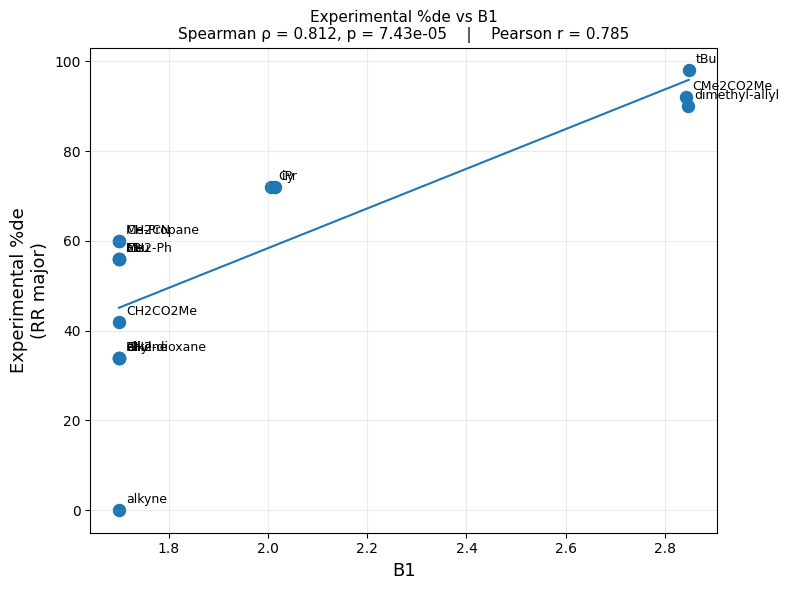

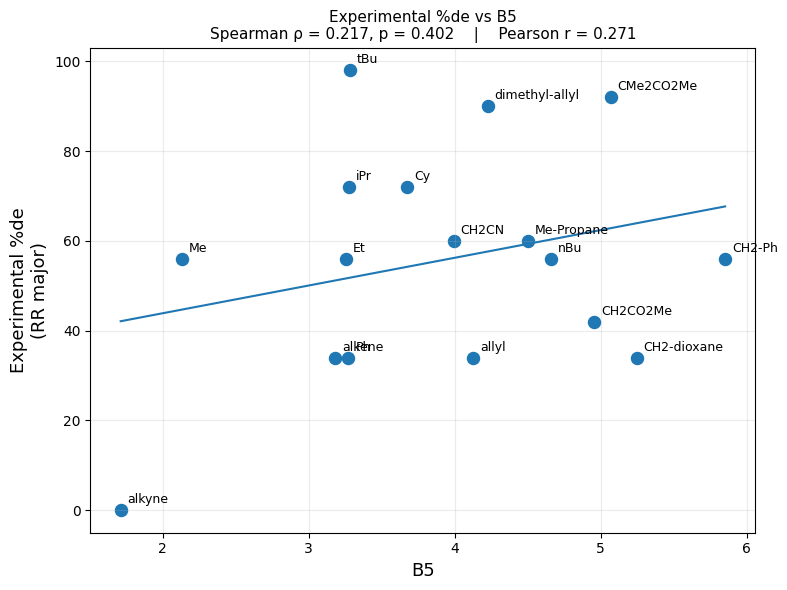

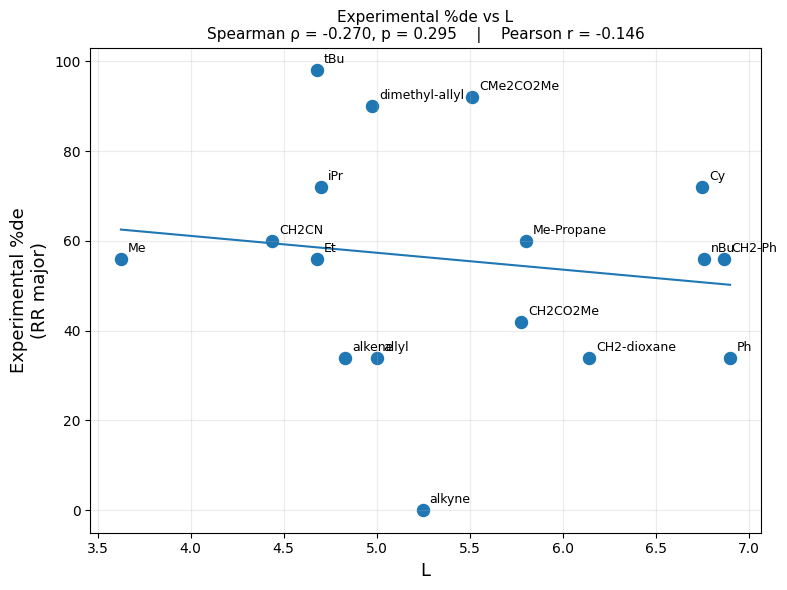

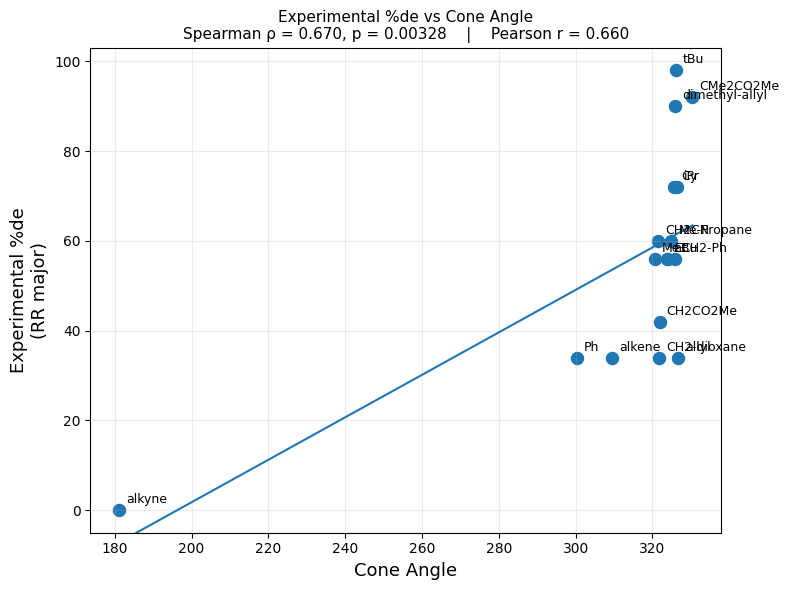

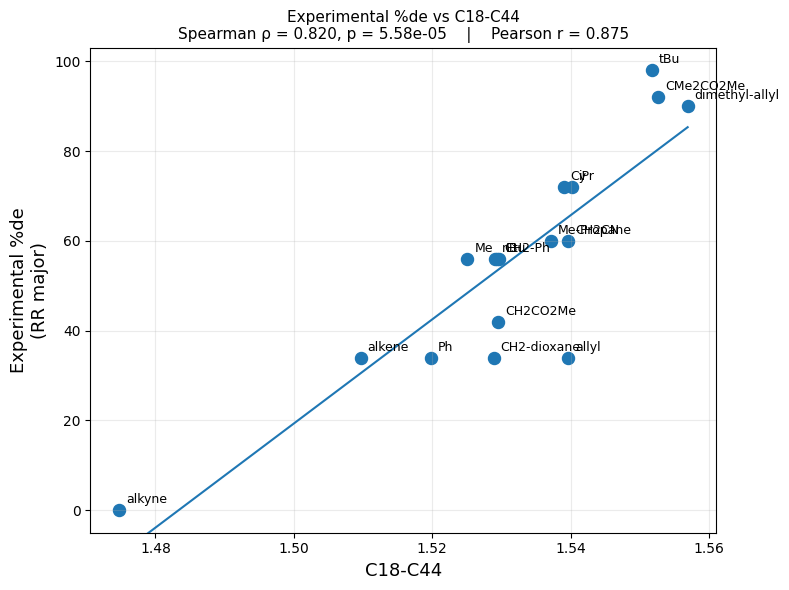

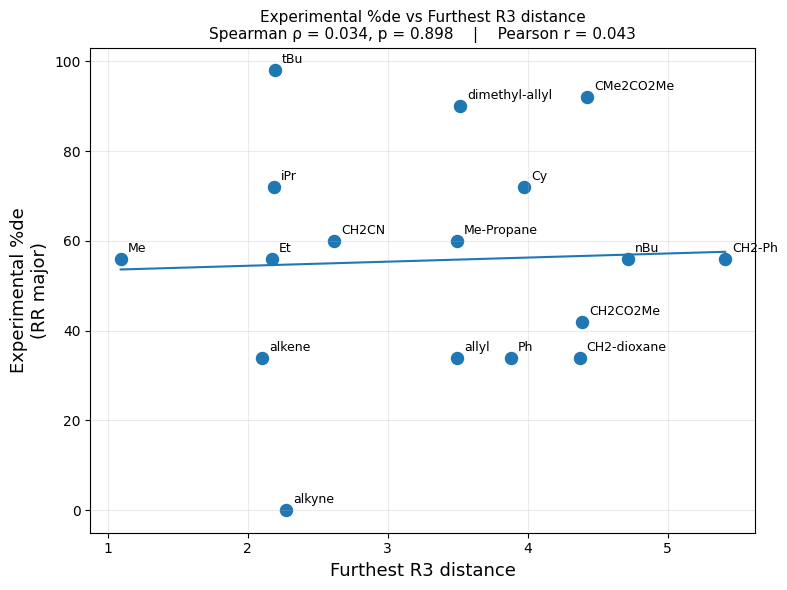

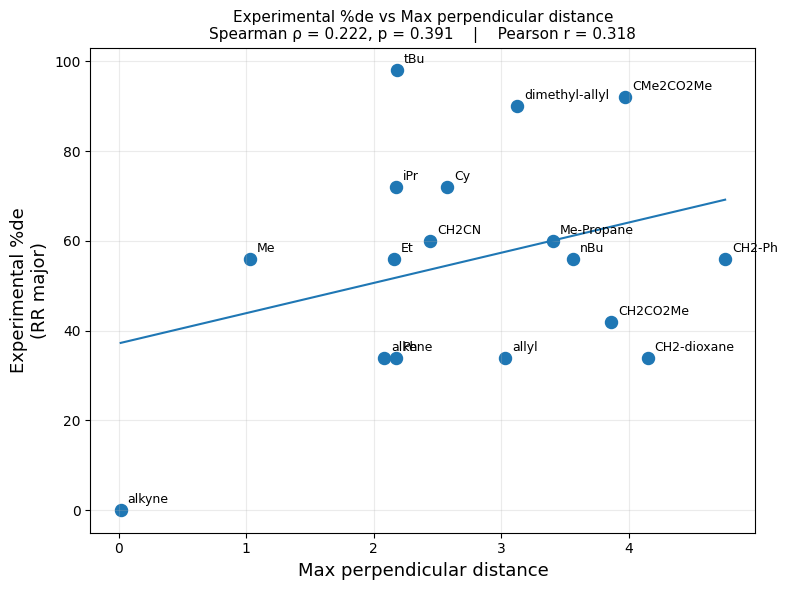



DONE

Excel file:
/content/drive/MyDrive/xyz_files/R3_%de_Correlation_Analysis.xlsx

PDF file:
/content/drive/MyDrive/xyz_files/R3_%de_Correlation_Diagrams.pdf


In [2]:
# ============================================================
# INSTALL
# ============================================================

!pip install -q pandas numpy openpyxl scipy matplotlib


# ============================================================
# IMPORTS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, pearsonr
from matplotlib.backends.backend_pdf import PdfPages
from google.colab import drive


# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================

drive.mount('/content/drive', force_remount=True)


# ============================================================
# PATH
# ============================================================

xyz_folder = "/content/drive/MyDrive/xyz_files"

input_file = os.path.join(
    xyz_folder,
    "ALL_R3_Steric_Parameters.xlsx"
)


# ============================================================
# CHECK FILE
# ============================================================

print("Checking file:")
print(input_file)

print("\nFile exists:",
      os.path.exists(input_file))


if not os.path.exists(input_file):

    raise FileNotFoundError(
        "ALL_R3_Steric_Parameters.xlsx "
        "was not found."
    )


# ============================================================
# READ CALCULATED STERIC DATA
# ============================================================

steric_df = pd.read_excel(
    input_file
)


print("\nCalculated data:")
display(steric_df)


# ============================================================
# EXPERIMENTAL DIastereoselectivity
#
# RR = MAJOR
# RS = MINOR
#
# Values are %de
# ============================================================

exp_data = {

    "RR_CH2-Ph.xyz": 56,

    "RR_CH2-dioxane.xyz": 34,

    "RR_CH2CN.xyz": 60,

    "RR_CH2CO2Me.xyz": 42,

    "RR_CMe2CO2Me.xyz": 92,

    "RR_Cy.xyz": 72,

    "RR_Et.xyz": 56,

    "RR_Me-Propane.xyz": 60,

    "RR_Me.xyz": 56,

    "RR_Ph.xyz": 34,

    "RR_alkene.xyz": 34,

    "RR_alkyne.xyz": 0,

    "RR_allyl.xyz": 34,

    "RR_dimethyl-allyl.xyz": 90,

    "RR_iPr.xyz": 72,

    "RR_nBu.xyz": 56,

    "RR_tBu.xyz": 98

}


exp_df = pd.DataFrame(

    list(exp_data.items()),

    columns=[
        "File",
        "Experimental_%de"
    ]

)


# ============================================================
# STANDARDIZE COLUMN NAMES
# ============================================================

rename_dict = {

    "Sterimol B1 (Å)": "B1",

    "B1 (Å)": "B1",

    "Sterimol B5 (Å)": "B5",

    "B5 (Å)": "B5",

    "Sterimol L (Å)": "L",

    "L (Å)": "L",

    "Cone Angle (deg)": "Cone Angle",

    "Cone Angle": "Cone Angle",

    "C18-C44 distance (Å)": "C18-C44",

    "C18-C44 (Å)": "C18-C44",

    "C44-furthest R3 distance (Å)":
        "Furthest R3 distance",

    "C44-furthest R3 (Å)":
        "Furthest R3 distance",

    "Max perpendicular distance (Å)":
        "Max perpendicular distance"

}


for old_name, new_name in rename_dict.items():

    if old_name in steric_df.columns:

        steric_df = steric_df.rename(

            columns={
                old_name: new_name
            }

        )


# ============================================================
# PARAMETERS TO CORRELATE
# ============================================================

parameters = [

    "B1",

    "B5",

    "L",

    "Cone Angle",

    "C18-C44",

    "Furthest R3 distance",

    "Max perpendicular distance"

]


# ============================================================
# CHECK PARAMETERS
# ============================================================

missing = [

    p

    for p in parameters

    if p not in steric_df.columns

]


if missing:

    print("\nMissing parameters:")

    print(missing)

    print("\nAvailable columns:")

    print(
        list(steric_df.columns)
    )

    raise ValueError(
        "Some required parameters are missing."
    )


# ============================================================
# MERGE EXPERIMENTAL + CALCULATED DATA
# ============================================================

df = exp_df.merge(

    steric_df,

    on="File",

    how="left"

)


# ============================================================
# R3 LABEL
# ============================================================

df["R3"] = (

    df["File"]

    .str.replace(
        "RR_",
        "",
        regex=False
    )

    .str.replace(
        ".xyz",
        "",
        regex=False
    )

)


# ============================================================
# CONVERT TO NUMERIC
# ============================================================

df["Experimental_%de"] = pd.to_numeric(

    df["Experimental_%de"],

    errors="coerce"

)


for p in parameters:

    df[p] = pd.to_numeric(

        df[p],

        errors="coerce"

    )


# ============================================================
# DISPLAY MERGED DATA
# ============================================================

print("\n")
print("=" * 70)
print("MERGED EXPERIMENTAL + CALCULATED DATA")
print("=" * 70)

display(

    df[
        ["File", "R3", "Experimental_%de"]
        + parameters
    ]

)


# ============================================================
# CORRELATION ANALYSIS
# ============================================================

correlation_results = []


for parameter in parameters:

    sub = df[
        [
            "R3",
            "Experimental_%de",
            parameter
        ]
    ].dropna()


    x = sub[parameter].values

    y = sub["Experimental_%de"].values


    # --------------------------------------------------------
    # Spearman
    # --------------------------------------------------------

    if (
        len(x) >= 3
        and len(np.unique(x)) > 1
    ):

        rho, rho_p = spearmanr(
            x,
            y
        )

    else:

        rho = np.nan
        rho_p = np.nan


    # --------------------------------------------------------
    # Pearson
    # --------------------------------------------------------

    if (
        len(x) >= 3
        and len(np.unique(x)) > 1
    ):

        r, r_p = pearsonr(
            x,
            y
        )

    else:

        r = np.nan
        r_p = np.nan


    correlation_results.append({

        "Parameter":
            parameter,

        "N":
            len(x),

        "Spearman rho":
            rho,

        "Spearman p-value":
            rho_p,

        "Pearson r":
            r,

        "Pearson p-value":
            r_p

    })


# ============================================================
# CORRELATION TABLE
# ============================================================

corr_df = pd.DataFrame(
    correlation_results
)


print("\n")
print("=" * 70)
print("CORRELATION STATISTICS")
print("=" * 70)

display(
    corr_df
)


# ============================================================
# CREATE PDF
# ============================================================

pdf_file = os.path.join(

    xyz_folder,

    "R3_%de_Correlation_Diagrams.pdf"

)


with PdfPages(pdf_file) as pdf:


    for parameter in parameters:


        sub = df[
            [
                "R3",
                "Experimental_%de",
                parameter
            ]
        ].dropna()


        x = sub[parameter].values

        y = sub["Experimental_%de"].values


        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        stat = corr_df[
            corr_df["Parameter"] == parameter
        ].iloc[0]


        # ----------------------------------------------------
        # Plot
        # ----------------------------------------------------

        fig, ax = plt.subplots(
            figsize=(8, 6)
        )


        ax.scatter(

            x,

            y,

            s=75

        )


        # ----------------------------------------------------
        # Linear trend line
        # ----------------------------------------------------

        if (

            len(x) >= 2

            and
            np.ptp(x) > 0

        ):

            slope, intercept = np.polyfit(

                x,

                y,

                1

            )


            xx = np.linspace(

                x.min(),

                x.max(),

                200

            )


            yy = (
                slope * xx
                + intercept
            )


            ax.plot(

                xx,

                yy

            )


        # ----------------------------------------------------
        # Label each R3
        # ----------------------------------------------------

        for _, row in sub.iterrows():

            ax.annotate(

                row["R3"],

                (
                    row[parameter],

                    row[
                        "Experimental_%de"
                    ]
                ),

                xytext=(5, 5),

                textcoords="offset points",

                fontsize=9

            )


        # ----------------------------------------------------
        # Axis labels
        # ----------------------------------------------------

        ax.set_xlabel(

            parameter,

            fontsize=13

        )


        ax.set_ylabel(

            "Experimental %de\n(RR major)",

            fontsize=13

        )


        # ----------------------------------------------------
        # Title
        # ----------------------------------------------------

        ax.set_title(

            f"Experimental %de vs {parameter}\n"
            f"Spearman ρ = "
            f"{stat['Spearman rho']:.3f}, "
            f"p = "
            f"{stat['Spearman p-value']:.3g}    |    "
            f"Pearson r = "
            f"{stat['Pearson r']:.3f}",

            fontsize=11

        )


        ax.set_ylim(
            -5,
            103
        )


        ax.grid(
            alpha=0.25
        )


        fig.tight_layout()


        pdf.savefig(
            fig
        )


        plt.show()

        plt.close(fig)


# ============================================================
# SAVE EXCEL
# ============================================================

excel_output = os.path.join(

    xyz_folder,

    "R3_%de_Correlation_Analysis.xlsx"

)


with pd.ExcelWriter(

    excel_output,

    engine="openpyxl"

) as writer:


    df.to_excel(

        writer,

        sheet_name="Merged_Data",

        index=False

    )


    corr_df.to_excel(

        writer,

        sheet_name="Correlation_Statistics",

        index=False

    )


# ============================================================
# FINAL MESSAGE
# ============================================================

print("\n")
print("=" * 70)
print("DONE")
print("=" * 70)

print(
    "\nExcel file:"
)

print(
    excel_output
)

print(
    "\nPDF file:"
)

print(
    pdf_file
)

Mounted at /content/drive
CHECKING INPUT FILE

Input file:
/content/drive/MyDrive/xyz_files/ALL_R3_Steric_Parameters.xlsx

File exists: True

Columns in Excel:
   File
   Status
   Number of atoms
   R3
   R3 atoms
   C18-C44 distance (Å)
   Furthest R3 atom
   C44-furthest R3 distance (Å)
   Max perpendicular atom
   Max perpendicular distance (Å)
   Sterimol B1 (Å)
   Sterimol B5 (Å)
   Sterimol L (Å)
   Cone Angle (deg)
   Error

Number of experimental compounds:
17


SPEARMAN CORRELATION MATRIX


,Experimental_%de,B1,B5,L,Cone_Angle,C18_C44,Furthest_R3,Max_Perpendicular
Experimental_%de,1.000,0.812,0.217,-0.270,0.670,0.820,0.034,0.222
B1,0.812,1.000,0.061,-0.216,0.658,0.757,0.002,0.081
B5,0.217,0.061,1.000,0.525,0.461,0.343,0.843,0.998
L,-0.270,-0.216,0.525,1.000,-0.047,-0.279,0.806,0.554
Cone_Angle,0.670,0.658,0.461,-0.047,1.000,0.865,0.250,0.475
C18_C44,0.820,0.757,0.343,-0.279,0.865,1.000,0.105,0.341
Furthest_R3,0.034,0.002,0.843,0.806,0.250,0.105,1.000,0.855
Max_Perpendicular,0.222,0.081,0.998,0.554,0.475,0.341,0.855,1.000




PEARSON CORRELATION MATRIX


,Experimental_%de,B1,B5,L,Cone_Angle,C18_C44,Furthest_R3,Max_Perpendicular
Experimental_%de,1.000,0.785,0.271,-0.146,0.660,0.875,0.043,0.318
B1,0.785,1.000,0.090,-0.174,0.218,0.613,0.008,0.113
B5,0.271,0.090,1.000,0.546,0.568,0.505,0.858,0.991
L,-0.146,-0.174,0.546,1.000,0.018,-0.070,0.856,0.539
Cone_Angle,0.660,0.218,0.568,0.018,1.000,0.850,0.248,0.643
C18_C44,0.875,0.613,0.505,-0.070,0.850,1.000,0.225,0.554
Furthest_R3,0.043,0.008,0.858,0.856,0.248,0.225,1.000,0.839
Max_Perpendicular,0.318,0.113,0.991,0.539,0.643,0.554,0.839,1.000




SPEARMAN CORRELATION WITH EXPERIMENTAL %de


,Parameter,N,Spearman rho,p-value
4,C18_C44,17,0.8200,0.0001
0,B1,17,0.8124,0.0001
3,Cone_Angle,17,0.6696,0.0033
2,L,17,-0.2696,0.2954
6,Max_Perpendicular,17,0.2224,0.3910
1,B5,17,0.2174,0.4019
5,Furthest_R3,17,0.0335,0.8983




PEARSON CORRELATION WITH EXPERIMENTAL %de


,Parameter,N,Pearson r,p-value
4,C18_C44,17,0.8746,0.0000
0,B1,17,0.7847,0.0002
3,Cone_Angle,17,0.6601,0.0039
6,Max_Perpendicular,17,0.3177,0.2140
1,B5,17,0.2708,0.2931
2,L,17,-0.1462,0.5755
5,Furthest_R3,17,0.0433,0.8690


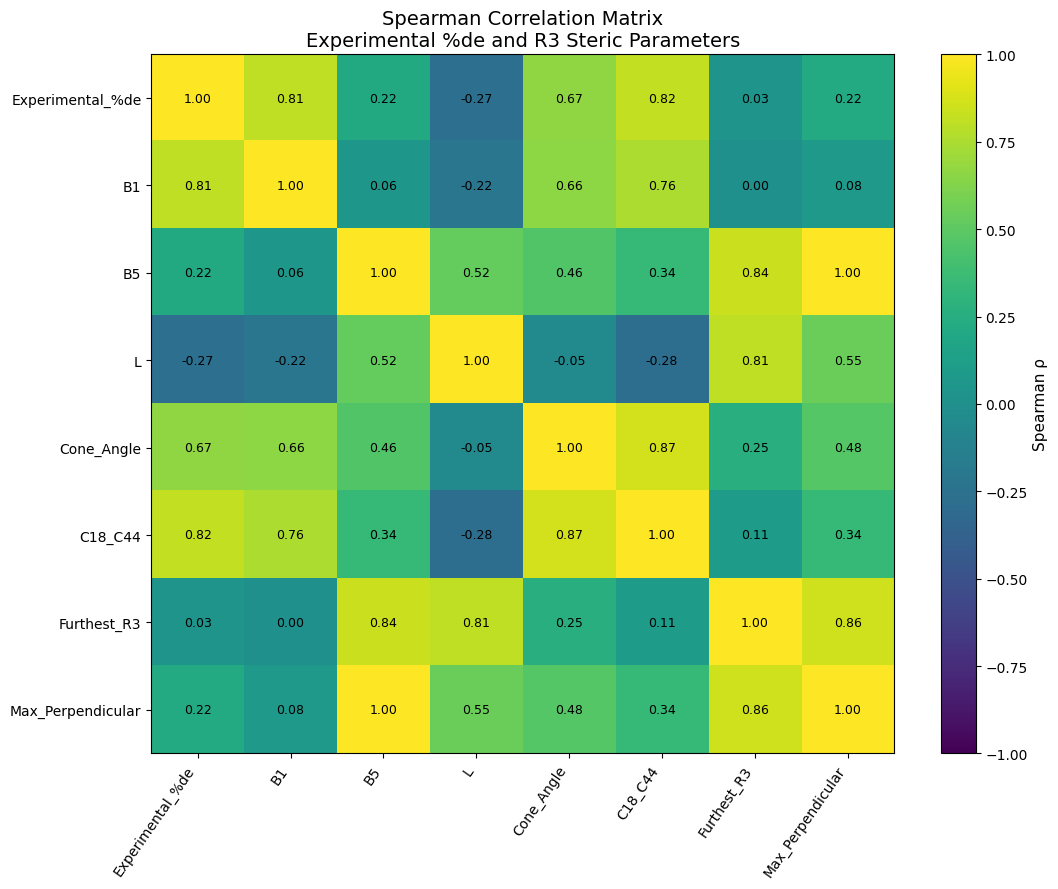

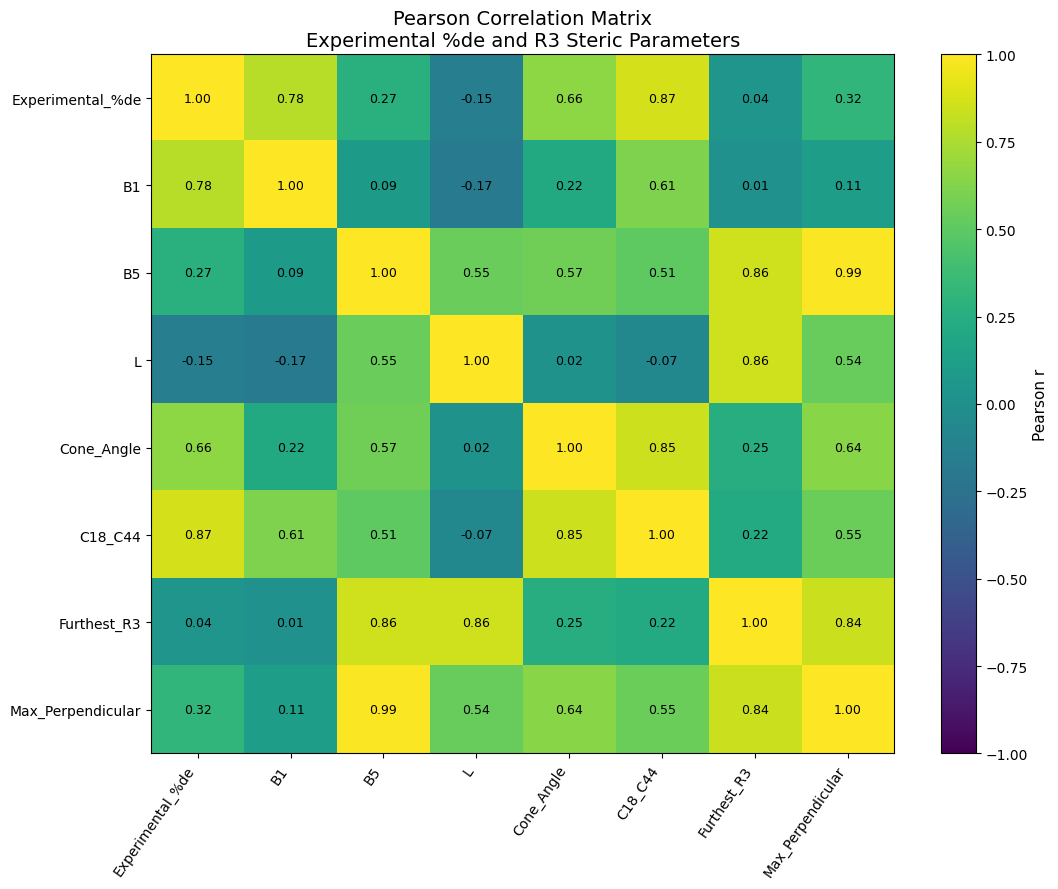



CORRELATION ANALYSIS COMPLETED

Number of compounds: 17

Excel:
/content/drive/MyDrive/xyz_files/R3_Correlation_Matrices.xlsx

PDF:
/content/drive/MyDrive/xyz_files/R3_Correlation_Matrices_Heatmaps.pdf

Spearman PNG:
/content/drive/MyDrive/xyz_files/Spearman_Correlation_Matrix.png

Pearson PNG:
/content/drive/MyDrive/xyz_files/Pearson_Correlation_Matrix.png


In [3]:
# ============================================================
# R3 STERIC PARAMETERS vs EXPERIMENTAL %de
# CORRELATION MATRIX
#
# RR = major product
# RS = minor product
#
# Input:
# ALL_R3_Steric_Parameters.xlsx
#
# Output:
# 1. R3_Correlation_Matrices.xlsx
# 2. R3_Correlation_Matrices_Heatmaps.pdf
# 3. Pearson heatmap
# 4. Spearman heatmap
# ============================================================


# ============================================================
# 1. INSTALL
# ============================================================

!pip install -q pandas numpy openpyxl scipy matplotlib


# ============================================================
# 2. IMPORTS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import spearmanr, pearsonr
from google.colab import drive
from matplotlib.backends.backend_pdf import PdfPages


# ============================================================
# 3. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=True
)


# ============================================================
# 4. FILE PATH
# ============================================================

xyz_folder = Path(
    "/content/drive/MyDrive/xyz_files"
)

input_file = (
    xyz_folder /
    "ALL_R3_Steric_Parameters.xlsx"
)


print("=" * 70)
print("CHECKING INPUT FILE")
print("=" * 70)

print(
    "\nInput file:"
)

print(input_file)

print(
    "\nFile exists:",
    input_file.exists()
)


if not input_file.exists():

    raise FileNotFoundError(
        "\nALL_R3_Steric_Parameters.xlsx "
        "was not found."
    )


# ============================================================
# 5. READ STERIC DATA
# ============================================================

steric_df = pd.read_excel(
    input_file
)


print("\nColumns in Excel:")

for col in steric_df.columns:
    print("  ", col)


# ============================================================
# 6. EXPERIMENTAL %de
#
# RR = MAJOR
# RS = MINOR
# ============================================================

exp_data = {

    "RR_CH2-Ph.xyz": 56,

    "RR_CH2-dioxane.xyz": 34,

    "RR_CH2CN.xyz": 60,

    "RR_CH2CO2Me.xyz": 42,

    "RR_CMe2CO2Me.xyz": 92,

    "RR_Cy.xyz": 72,

    "RR_Et.xyz": 56,

    "RR_Me-Propane.xyz": 60,

    "RR_Me.xyz": 56,

    "RR_Ph.xyz": 34,

    "RR_alkene.xyz": 34,

    "RR_alkyne.xyz": 0,

    "RR_allyl.xyz": 34,

    "RR_dimethyl-allyl.xyz": 90,

    "RR_iPr.xyz": 72,

    "RR_nBu.xyz": 56,

    "RR_tBu.xyz": 98

}


exp_df = pd.DataFrame(

    list(exp_data.items()),

    columns=[
        "File",
        "Experimental_%de"
    ]

)


print("\nNumber of experimental compounds:")

print(
    len(exp_df)
)


# ============================================================
# 7. STANDARDIZE COLUMN NAMES
# ============================================================

rename_dict = {

    "Sterimol B1 (Å)": "B1",

    "B1 (Å)": "B1",

    "Sterimol B5 (Å)": "B5",

    "B5 (Å)": "B5",

    "Sterimol L (Å)": "L",

    "L (Å)": "L",

    "Cone Angle (deg)": "Cone_Angle",

    "Cone Angle": "Cone_Angle",

    "C18-C44 distance (Å)": "C18_C44",

    "C18-C44 (Å)": "C18_C44",

    "C44-furthest R3 distance (Å)":
        "Furthest_R3",

    "C44-furthest R3 (Å)":
        "Furthest_R3",

    "Max perpendicular distance (Å)":
        "Max_Perpendicular"

}


for old_name, new_name in rename_dict.items():

    if old_name in steric_df.columns:

        steric_df = steric_df.rename(

            columns={
                old_name: new_name
            }

        )


# ============================================================
# 8. PARAMETERS FOR CORRELATION
# ============================================================

parameters = [

    "B1",

    "B5",

    "L",

    "Cone_Angle",

    "C18_C44",

    "Furthest_R3",

    "Max_Perpendicular"

]


# ============================================================
# 9. CHECK PARAMETERS
# ============================================================

missing = [

    p

    for p in parameters

    if p not in steric_df.columns

]


if missing:

    print(
        "\nMissing parameters:"
    )

    for p in missing:
        print(
            "  ",
            p
        )

    print(
        "\nAvailable columns:"
    )

    print(
        list(steric_df.columns)
    )

    raise ValueError(
        "\nRequired parameters are missing."
    )


# ============================================================
# 10. MERGE EXPERIMENTAL + CALCULATED DATA
# ============================================================

df = exp_df.merge(

    steric_df,

    on="File",

    how="left"

)


# ============================================================
# 11. R3 NAME
# ============================================================

df["R3"] = (

    df["File"]

    .str.replace(
        "RR_",
        "",
        regex=False
    )

    .str.replace(
        ".xyz",
        "",
        regex=False
    )

)


# ============================================================
# 12. CONVERT TO NUMERIC
# ============================================================

df["Experimental_%de"] = pd.to_numeric(

    df["Experimental_%de"],

    errors="coerce"

)


for p in parameters:

    df[p] = pd.to_numeric(

        df[p],

        errors="coerce"

    )


# ============================================================
# 13. SELECT DATA FOR CORRELATION
# ============================================================

correlation_columns = [

    "Experimental_%de"

] + parameters


correlation_data = df[
    correlation_columns
].copy()


# ============================================================
# 14. SPEARMAN CORRELATION MATRIX
# ============================================================

spearman_matrix = correlation_data.corr(

    method="spearman"

)


# ============================================================
# 15. PEARSON CORRELATION MATRIX
# ============================================================

pearson_matrix = correlation_data.corr(

    method="pearson"

)


# ============================================================
# 16. PRINT SPEARMAN MATRIX
# ============================================================

print("\n")
print("=" * 70)
print("SPEARMAN CORRELATION MATRIX")
print("=" * 70)

display(
    spearman_matrix.round(3)
)


# ============================================================
# 17. PRINT PEARSON MATRIX
# ============================================================

print("\n")
print("=" * 70)
print("PEARSON CORRELATION MATRIX")
print("=" * 70)

display(
    pearson_matrix.round(3)
)


# ============================================================
# 18. SPEARMAN CORRELATION WITH %de ONLY
# ============================================================

print("\n")
print("=" * 70)
print("SPEARMAN CORRELATION WITH EXPERIMENTAL %de")
print("=" * 70)


spearman_results = []


for p in parameters:

    sub = df[
        [
            "Experimental_%de",
            p
        ]
    ].dropna()


    rho, p_value = spearmanr(

        sub["Experimental_%de"],

        sub[p]

    )


    spearman_results.append({

        "Parameter":
            p,

        "N":
            len(sub),

        "Spearman rho":
            rho,

        "p-value":
            p_value

    })


spearman_results_df = pd.DataFrame(

    spearman_results

)


display(

    spearman_results_df.sort_values(

        "Spearman rho",

        key=lambda x: x.abs(),

        ascending=False

    ).round(4)

)


# ============================================================
# 19. PEARSON CORRELATION WITH %de ONLY
# ============================================================

print("\n")
print("=" * 70)
print("PEARSON CORRELATION WITH EXPERIMENTAL %de")
print("=" * 70)


pearson_results = []


for p in parameters:

    sub = df[
        [
            "Experimental_%de",
            p
        ]
    ].dropna()


    r, p_value = pearsonr(

        sub["Experimental_%de"],

        sub[p]

    )


    pearson_results.append({

        "Parameter":
            p,

        "N":
            len(sub),

        "Pearson r":
            r,

        "p-value":
            p_value

    })


pearson_results_df = pd.DataFrame(

    pearson_results

)


display(

    pearson_results_df.sort_values(

        "Pearson r",

        key=lambda x: x.abs(),

        ascending=False

    ).round(4)

)


# ============================================================
# 20. CREATE SPEARMAN HEATMAP
# ============================================================

fig, ax = plt.subplots(

    figsize=(11, 9)

)


im = ax.imshow(

    spearman_matrix.values,

    vmin=-1,

    vmax=1,

    aspect="auto"

)


ax.set_xticks(

    range(
        len(spearman_matrix.columns)
    )

)


ax.set_yticks(

    range(
        len(spearman_matrix.index)
    )

)


ax.set_xticklabels(

    spearman_matrix.columns,

    rotation=55,

    ha="right",

    fontsize=10

)


ax.set_yticklabels(

    spearman_matrix.index,

    fontsize=10

)


# Values inside cells

for i in range(
    len(spearman_matrix.index)
):

    for j in range(
        len(spearman_matrix.columns)
    ):

        value = spearman_matrix.iloc[i, j]

        ax.text(

            j,

            i,

            f"{value:.2f}",

            ha="center",

            va="center",

            fontsize=9

        )


ax.set_title(

    "Spearman Correlation Matrix\n"
    "Experimental %de and R3 Steric Parameters",

    fontsize=14

)


cbar = fig.colorbar(

    im,

    ax=ax

)


cbar.set_label(

    "Spearman ρ",

    fontsize=11

)


fig.tight_layout()


# ============================================================
# SAVE SPEARMAN FIGURE
# ============================================================

spearman_png = (

    xyz_folder /

    "Spearman_Correlation_Matrix.png"

)


fig.savefig(

    spearman_png,

    dpi=300,

    bbox_inches="tight"

)


plt.show()

plt.close(fig)


# ============================================================
# 21. CREATE PEARSON HEATMAP
# ============================================================

fig, ax = plt.subplots(

    figsize=(11, 9)

)


im = ax.imshow(

    pearson_matrix.values,

    vmin=-1,

    vmax=1,

    aspect="auto"

)


ax.set_xticks(

    range(
        len(pearson_matrix.columns)
    )

)


ax.set_yticks(

    range(
        len(pearson_matrix.index)
    )

)


ax.set_xticklabels(

    pearson_matrix.columns,

    rotation=55,

    ha="right",

    fontsize=10

)


ax.set_yticklabels(

    pearson_matrix.index,

    fontsize=10

)


for i in range(
    len(pearson_matrix.index)
):

    for j in range(
        len(pearson_matrix.columns)
    ):

        value = pearson_matrix.iloc[i, j]

        ax.text(

            j,

            i,

            f"{value:.2f}",

            ha="center",

            va="center",

            fontsize=9

        )


ax.set_title(

    "Pearson Correlation Matrix\n"
    "Experimental %de and R3 Steric Parameters",

    fontsize=14

)


cbar = fig.colorbar(

    im,

    ax=ax

)


cbar.set_label(

    "Pearson r",

    fontsize=11

)


fig.tight_layout()


# ============================================================
# SAVE PEARSON FIGURE
# ============================================================

pearson_png = (

    xyz_folder /

    "Pearson_Correlation_Matrix.png"

)


fig.savefig(

    pearson_png,

    dpi=300,

    bbox_inches="tight"

)


plt.show()

plt.close(fig)


# ============================================================
# 22. SAVE BOTH HEATMAPS INTO ONE PDF
# ============================================================

pdf_file = (

    xyz_folder /

    "R3_Correlation_Matrices_Heatmaps.pdf"

)


with PdfPages(pdf_file) as pdf:

    # -----------------------------
    # Spearman
    # -----------------------------

    fig, ax = plt.subplots(

        figsize=(11, 9)

    )


    im = ax.imshow(

        spearman_matrix.values,

        vmin=-1,

        vmax=1,

        aspect="auto"

    )


    ax.set_xticks(

        range(
            len(spearman_matrix.columns)
        )

    )

    ax.set_yticks(

        range(
            len(spearman_matrix.index)
        )

    )


    ax.set_xticklabels(

        spearman_matrix.columns,

        rotation=55,

        ha="right"

    )


    ax.set_yticklabels(

        spearman_matrix.index

    )


    for i in range(
        len(spearman_matrix.index)
    ):

        for j in range(
            len(spearman_matrix.columns)
        ):

            ax.text(

                j,

                i,

                f"{spearman_matrix.iloc[i,j]:.2f}",

                ha="center",

                va="center"

            )


    ax.set_title(

        "Spearman Correlation Matrix"

    )


    fig.colorbar(

        im,

        ax=ax,

        label="Spearman ρ"

    )


    fig.tight_layout()

    pdf.savefig(fig)

    plt.close(fig)


    # -----------------------------
    # Pearson
    # -----------------------------

    fig, ax = plt.subplots(

        figsize=(11, 9)

    )


    im = ax.imshow(

        pearson_matrix.values,

        vmin=-1,

        vmax=1,

        aspect="auto"

    )


    ax.set_xticks(

        range(
            len(pearson_matrix.columns)
        )

    )

    ax.set_yticks(

        range(
            len(pearson_matrix.index)
        )

    )


    ax.set_xticklabels(

        pearson_matrix.columns,

        rotation=55,

        ha="right"

    )


    ax.set_yticklabels(

        pearson_matrix.index

    )


    for i in range(
        len(pearson_matrix.index)
    ):

        for j in range(
            len(pearson_matrix.columns)
        ):

            ax.text(

                j,

                i,

                f"{pearson_matrix.iloc[i,j]:.2f}",

                ha="center",

                va="center"

            )


    ax.set_title(

        "Pearson Correlation Matrix"

    )


    fig.colorbar(

        im,

        ax=ax,

        label="Pearson r"

    )


    fig.tight_layout()

    pdf.savefig(fig)

    plt.close(fig)


# ============================================================
# 23. SAVE EVERYTHING TO EXCEL
# ============================================================

excel_output = (

    xyz_folder /

    "R3_Correlation_Matrices.xlsx"

)


with pd.ExcelWriter(

    excel_output,

    engine="openpyxl"

) as writer:


    # Original merged data

    df.to_excel(

        writer,

        sheet_name="Merged_Data",

        index=False

    )


    # Spearman matrix

    spearman_matrix.to_excel(

        writer,

        sheet_name="Spearman_Matrix"

    )


    # Pearson matrix

    pearson_matrix.to_excel(

        writer,

        sheet_name="Pearson_Matrix"

    )


    # Spearman statistics

    spearman_results_df.to_excel(

        writer,

        sheet_name="Spearman_%de",

        index=False

    )


    # Pearson statistics

    pearson_results_df.to_excel(

        writer,

        sheet_name="Pearson_%de",

        index=False

    )


# ============================================================
# 24. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("CORRELATION ANALYSIS COMPLETED")
print("=" * 70)


print(
    "\nNumber of compounds:",
    len(df)
)


print(
    "\nExcel:"
)

print(
    excel_output
)


print(
    "\nPDF:"
)

print(
    pdf_file
)


print(
    "\nSpearman PNG:"
)

print(
    spearman_png
)


print(
    "\nPearson PNG:"
)

print(
    pearson_png
)